# 🚗⚡ EV Market Argentina — Growth Analysis & 2030 Forecast

## Overview

Argentina's electric and hybrid vehicle market experienced an unprecedented transformation in 2025-2026, driven by the regulatory framework of **Decreto 49/2025**, which established preferential tariff conditions for EV imports.

This project analyzes:
- 📈 **Historical vehicle registration trends** (2000–2026) using official DNRPA data
- ⚡ **EV & hybrid adoption** by technology type (HEV, MHEV, BEV, PHEV)
- 🌍 **Geographic distribution** of registrations across Argentina's provinces
- 🔋 **2030 forecast** for EV penetration under different growth scenarios
- 🗺️ **Charging network analysis** — current coverage vs. projected demand

## Data Sources

| Source | Description | Period |
|--------|-------------|--------|
| DNRPA / datos.gob.ar | Official vehicle registrations by province and month | 2000–2026 |
| SIOMAA / ACARA | EV & hybrid market report — technology breakdown | Q1 2026 |
| ACARA | Full market ranking — brands and models | March 2026 |

## Key Questions

1. How did the import opening reshape the Argentine auto market?
2. Which technologies are driving EV growth — and which brands entered the market?
3. What does the 2030 EV penetration look like under conservative vs. optimistic scenarios?
4. How many charging stations will Argentina need — and where?

---

---

## 📂 Data Sources — Full Detail

### 1. DNRPA — Dirección Nacional de los Registros de la Propiedad del Automotor
- **Dataset**: Estadística de inscripciones iniciales de automotores (0km)
- **Source**: [datos.gob.ar](https://datos.gob.ar/dataset/justicia-estadistica-tramites-automotores)
- **Publisher**: Ministerio de Justicia de la Nación Argentina
- **Coverage**: January 2000 — March 2026
- **Granularity**: Monthly, by province (24 provinces)
- **File**: `estadistica-inscripciones-iniciales-automotores-2000-01-2026-03.csv`
- **License**: Open Data — Licencia Creative Commons Attribution 4.0

### 2. SIOMAA — Sistema de Información sobre Movilidad Automotriz Argentina
- **Report**: Informe Trimestral sobre Electromovilidad — Automóviles y Comerciales Livianos
- **Source**: [siomaa.com](https://www.siomaa.com/Reports)
- **Publisher**: SIOMAA SA — in collaboration with ACARA
- **Coverage**: Q1 2026 (with historical data from 2018)
- **Content**: EV & hybrid registrations by technology (HEV, MHEV, BEV, PHEV), brand, model, and country of origin
- **File**: `SIOMAA_Informe_Electromovilidad_1Q2026.pdf`

### 3. ACARA — Asociación de Concesionarios de Automotores de la República Argentina
- **Report**: Estadística mensual de patentamientos — Marzo 2026
- **Source**: [acara.org.ar](https://www.acara.org.ar)
- **Publisher**: ACARA / DNRPA
- **Coverage**: March 2026 (with YTD and YoY comparisons)
- **Content**: Full market ranking — brands, models, provinces, 100% electric vehicles
- **File**: `ACARA_Marzo_2026.pdf`

### 4. Estaciones de carga — Red actual Argentina
- **Content**: Geographic location of existing EV charging stations in Argentina
- **Source**: Image provided (`Estaciones.PNG`) — based on publicly available charging network data
- **Note**: Used for visual reference of current charging infrastructure coverage

---

> **Note on data integration**: DNRPA provides total market volume; SIOMAA/ACARA provides EV/hybrid breakdown. These two sources are combined to calculate EV penetration rates and build the 2030 forecast model.

---

In [1]:
# ═══════════════════════════════════════════════════════════
# 📦 1.1 IMPORTS & DATA LOADING
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Settings ─────────────────────────────────────────────────
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✅ Libraries imported successfully")

# ── Load DNRPA dataset ───────────────────────────────────────
df = pd.read_csv(
    "estadistica-inscripciones-iniciales-automotores-2000-01-2026-03.csv",
    sep=";"
)

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📅 Years covered: {df['anio_inscripcion_inicial'].min()} — {df['anio_inscripcion_inicial'].max()}")
print(f"🗺️  Provinces: {df['provincia_inscripcion_inicial'].nunique()}")
print(f"🚗 Vehicle types: {df['tipo_vehiculo'].unique()}")
print(f"\n📋 Column names:\n{df.columns.tolist()}")
print(f"\n👀 Preview:")
display(df.head())

✅ Libraries imported successfully

📊 Dataset shape: (7560, 7)
📅 Years covered: 2000 — 2026
🗺️  Provinces: 24
🚗 Vehicle types: ['Automotores']

📋 Column names:
['tipo_vehiculo', 'anio_inscripcion_inicial', 'mes_inscripcion_inicial', 'provincia_inscripcion_inicial', 'letra_provincia_inscripcion_inicial', 'cantidad_inscripciones_iniciales', 'provincia_id']

👀 Preview:


,tipo_vehiculo,anio_inscripcion_inicial,mes_inscripcion_inicial,provincia_inscripcion_inicial,letra_provincia_inscripcion_inicial,cantidad_inscripciones_iniciales,provincia_id
0,Automotores,2000,1,Buenos Aires,B,16346,6
1,Automotores,2000,1,Catamarca,K,361,10
2,Automotores,2000,1,Chaco,H,551,22
3,Automotores,2000,1,Chubut,U,802,26
4,Automotores,2000,1,Ciudad Autónoma de Bs.As.,C,8892,2


📊 1.2 – ANNUAL REGISTRATION TREND
 year  registrations  registrations_annualized
 2000         352811                  352811.0
 2001         206653                  206653.0
 2002         101231                  101231.0
 2003         146047                  146047.0
 2004         292479                  292479.0
 2005         389234                  389234.0
 2006         452582                  452582.0
 2007         572841                  572841.0
 2008         615256                  615256.0
 2009         516799                  516799.0
 2010         665552                  665552.0
 2011         860820                  860820.0
 2012         845562                  845562.0
 2013         963598                  963598.0
 2014         689595                  689595.0
 2015         658535                  658535.0
 2016         712194                  712194.0
 2017         903405                  903405.0
 2018         805526                  805526.0
 2019         461944      

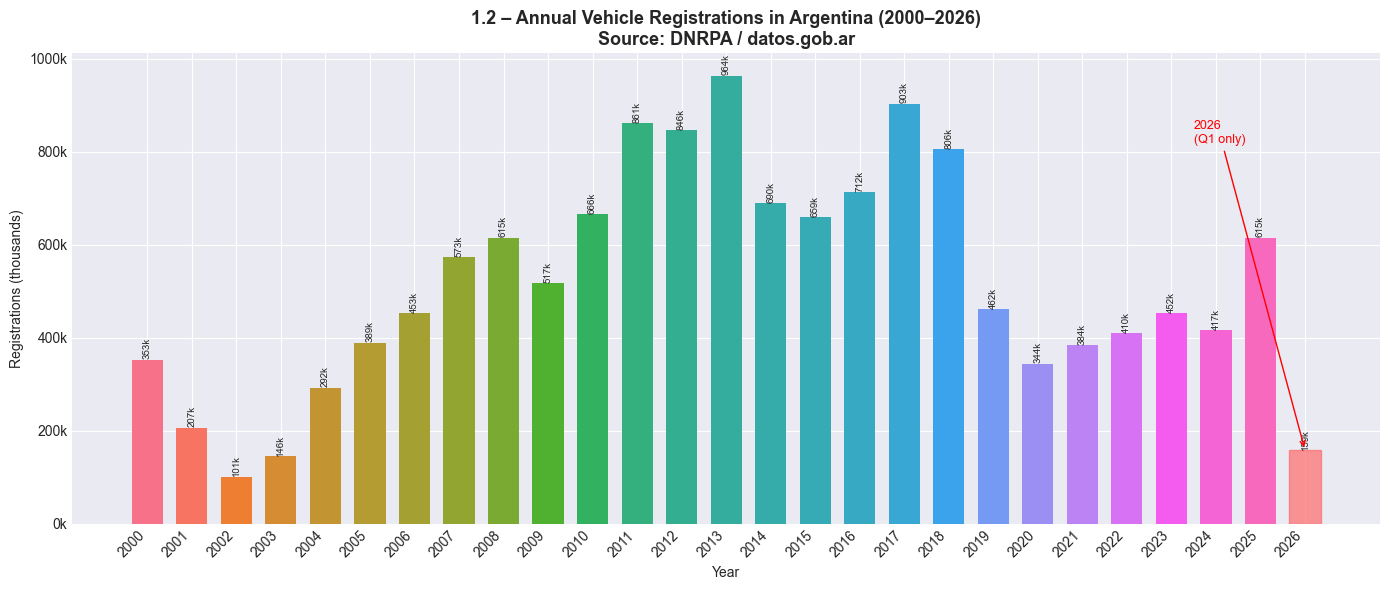


✅ Section 1.2 completed.


In [2]:
# ═══════════════════════════════════════════════════════════
# 📊 1.2 ANNUAL REGISTRATION TREND (2000–2026)
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📊 1.2 – ANNUAL REGISTRATION TREND")
print("=" * 60)

# ── Aggregate by year ────────────────────────────────────────
annual = (
    df.groupby("anio_inscripcion_inicial")["cantidad_inscripciones_iniciales"]
    .sum()
    .reset_index()
    .rename(columns={
        "anio_inscripcion_inicial": "year",
        "cantidad_inscripciones_iniciales": "registrations"
    })
)

# ── Annualize 2026 (only 3 months available) ─────────────────
annual.loc[annual["year"] == 2026, "registrations_annualized"] = (
    annual.loc[annual["year"] == 2026, "registrations"] / 3 * 12
)
annual["registrations_annualized"] = annual["registrations_annualized"].fillna(
    annual["registrations"]
)

print(annual.to_string(index=False))

# ── VISUALIZATION ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(annual["year"], annual["registrations"] / 1000,
              color=sns.color_palette("husl", len(annual)), width=0.7)

# Highlight 2026 as partial
bars[-1].set_color("#FF6B6B")
bars[-1].set_alpha(0.7)

ax.set_title("1.2 – Annual Vehicle Registrations in Argentina (2000–2026)\n"
             "Source: DNRPA / datos.gob.ar",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Registrations (thousands)")
ax.set_xticks(annual["year"])
ax.set_xticklabels(annual["year"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

# Add value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{bar.get_height():.0f}k", ha="center", fontsize=7, rotation=90)

# Annotate 2026 as partial
ax.annotate("2026\n(Q1 only)", xy=(2026, annual[annual["year"]==2026]["registrations"].values[0]/1000),
            xytext=(2023.5, annual["registrations"].max()/1000 * 0.85),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=9, color="red")

plt.tight_layout()
plt.show()

print("\n✅ Section 1.2 completed.")

### 📌 Key Observations — Annual Registrations (2000–2026)

**Argentina's auto market is highly cyclical**, reflecting the country's economic volatility:

- **2001–2002**: Collapse following the economic crisis — registrations dropped to **101k**, the lowest point in 25 years
- **2004–2013**: Sustained recovery driven by economic growth, reaching the **all-time peak of 904k units** in 2013
- **2014–2016**: Correction phase after the peak — inflation and currency controls dampened demand
- **2017–2018**: Second peak at **903k units**, fueled by credit expansion and import liberalization
- **2019–2021**: Sharp decline — macroeconomic instability, pandemic, and supply chain disruptions pushed the market to **344k** in 2021
- **2022–2025**: Gradual recovery toward **615k in 2025**
- **2026 (Q1 only)**: 157k registrations in 3 months — annualized projection of ~**630k units**

> **Context for EV analysis**: Total market volume sets the denominator for EV penetration rates. Even modest EV share percentages represent significant absolute volumes in a market of this size.

In [3]:
# ═══════════════════════════════════════════════════════════
# 📦 1.3 CONSOLIDATE MONTHLY DNRPA FILES (2018–2026)
# ═══════════════════════════════════════════════════════════

import os
import glob

print("=" * 60)
print("📦 1.3 – CONSOLIDATING MONTHLY DNRPA FILES")
print("=" * 60)

# ── Define path and find all files ──────────────────────────
data_path = "data/"
files = sorted(glob.glob(os.path.join(data_path, "dnrpa-inscripciones-iniciales-autos-*.csv")))

print(f"📁 Files found: {len(files)}")
print(f"   First: {os.path.basename(files[0])}")
print(f"   Last:  {os.path.basename(files[-1])}")

# ── Define passenger car types ───────────────────────────────
PASSENGER_TYPES = [
    "SEDAN 5 PUERTAS",
    "SEDAN 4 PUERTAS",
    "SEDAN 3 PUERTAS",
    "RURAL 5 PUERTAS",
    "RURAL 3 PUERTAS",
    "TODO TERRENO",
    "COUPE",
    "DESCAPOTABLE",
    "MINIBUS",
]

# ── Load and consolidate ─────────────────────────────────────
chunks = []
for f in files:
    try:
        tmp = pd.read_csv(f, low_memory=False)
        # Extract year and month from filename
        basename = os.path.basename(f)
        ym = basename.replace("dnrpa-inscripciones-iniciales-autos-", "").replace(".csv", "")
        tmp["year"] = int(ym[:4])
        tmp["month"] = int(ym[4:])
        chunks.append(tmp)
    except Exception as e:
        print(f"⚠️  Error reading {f}: {e}")

df_raw = pd.concat(chunks, ignore_index=True)
print(f"\n✅ Raw consolidated dataset: {df_raw.shape[0]:,} rows")

# ── Filter passenger cars only ───────────────────────────────
df_cars = df_raw[df_raw["automotor_tipo_descripcion"].isin(PASSENGER_TYPES)].copy()
print(f"🚗 Passenger cars only: {df_cars.shape[0]:,} rows")

# ── Summary by year ──────────────────────────────────────────
summary = df_cars.groupby("year").size().reset_index(name="registrations")
print(f"\n📊 Registrations by year (passenger cars):")
print(summary.to_string(index=False))

print("\n✅ Section 1.3 completed.")

📦 1.3 – CONSOLIDATING MONTHLY DNRPA FILES
📁 Files found: 99
   First: dnrpa-inscripciones-iniciales-autos-201801.csv
   Last:  dnrpa-inscripciones-iniciales-autos-202603.csv

✅ Raw consolidated dataset: 4,046,940 rows
🚗 Passenger cars only: 2,636,378 rows

📊 Registrations by year (passenger cars):
 year  registrations
 2018         610722
 2019         333070
 2020         232054
 2021         238549
 2022         252521
 2023         255296
 2024         235702
 2025         376421
 2026         102043

✅ Section 1.3 completed.


In [4]:
# ═══════════════════════════════════════════════════════════
# 🔍 1.4 VALIDATION — Cross-check with DNRPA summary CSV
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🔍 1.4 – VALIDATION")
print("=" * 60)

# ── Check what vehicle types exist in raw data ───────────────
print("📋 All vehicle types in raw dataset:")
print(df_raw["automotor_tipo_descripcion"].value_counts().head(30).to_string())

print(f"\n📋 Vehicle types included in PASSENGER_TYPES filter:")
for t in PASSENGER_TYPES:
    count = df_raw[df_raw["automotor_tipo_descripcion"] == t].shape[0]
    print(f"  • {t:<30}: {count:>10,}")

# ── Cross-check 2018 with summary CSV ────────────────────────
print(f"\n🔎 Cross-check 2018:")
print(f"  Monthly files (passenger cars): {summary[summary['year']==2018]['registrations'].values[0]:,}")
print(f"  Summary CSV total 2018:         {df[df['anio_inscripcion_inicial']==2018]['cantidad_inscripciones_iniciales'].sum():,}")

# ── Check tramite_tipo distribution ─────────────────────────
print(f"\n📋 tramite_tipo distribution in raw data:")
print(df_raw["tramite_tipo"].value_counts().to_string())

🔍 1.4 – VALIDATION
📋 All vehicle types in raw dataset:
automotor_tipo_descripcion
SEDAN 5 PUERTAS                 1343147
SEDAN 4 PUERTAS                  643018
PICK-UP                          593307
RURAL 5 PUERTAS                  515067
PICK-UP CABINA DOBLE             217749
FURGON                           196261
TODO TERRENO                     121440
RURAL 4/5 PUERTAS                 95514
SEMIRREMOLQUE                     53357
CHASIS CON CABINA                 31194
TRACTOR C/CABINA DORMITORIO       29401
FURGONETA                         27554
ACOPLADO                          27273
CHASIS C/CABINA                   26281
PICK-UP CABINA SIMPLE             17960
TRACTOR C/ CABINA DORMITORIO      15214
CHASIS SIN CABINA                 11914
CHASIS S/CABINA                    9468
CHASIS C/CABINA DORMITORIO         8486
SEDAN 3 PUERTAS                    8139
TRANS.DE PASAJEROS                 7789
CHASIS CON CABINA DORMITORIO       7386
MIDIBUS                            581

In [5]:
# ── Corrected passenger car types ───────────────────────────
PASSENGER_TYPES_V2 = [
    "SEDAN 5 PUERTAS",
    "SEDAN 4 PUERTAS",
    "SEDAN 3 PUERTAS",
    "RURAL 5 PUERTAS",
    "RURAL 4/5 PUERTAS",
    "RURAL 3 PUERTAS",
    "TODO TERRENO",
    "COUPE",
    "DESCAPOTABLE",
]

df_cars = df_raw[df_raw["automotor_tipo_descripcion"].isin(PASSENGER_TYPES_V2)].copy()

summary_v2 = df_cars.groupby("year").size().reset_index(name="registrations")

print("📊 Registrations by year — CORRECTED (passenger cars only):")
print(summary_v2.to_string(index=False))
print(f"\nTotal rows: {df_cars.shape[0]:,}")

📊 Registrations by year — CORRECTED (passenger cars only):
 year  registrations
 2018         610722
 2019         333070
 2020         232054
 2021         241144
 2022         261110
 2023         274902
 2024         261435
 2025         410560
 2026         106895

Total rows: 2,731,892


In [6]:
print("📋 Todos los tipos en df_cars:")
print(df_cars["automotor_tipo_descripcion"].value_counts().to_string())

📋 Todos los tipos en df_cars:
automotor_tipo_descripcion
SEDAN 5 PUERTAS      1343147
SEDAN 4 PUERTAS       643018
RURAL 5 PUERTAS       515067
TODO TERRENO          121440
RURAL 4/5 PUERTAS      95514
SEDAN 3 PUERTAS         8139
COUPE                   4428
DESCAPOTABLE            1133
RURAL 3 PUERTAS            6


In [7]:
print("📋 Sample RURAL 5 PUERTAS:")
print(df_cars[df_cars["automotor_tipo_descripcion"]=="RURAL 5 PUERTAS"]["automotor_marca_descripcion"].value_counts().head(10).to_string())

print("\n📋 Sample TODO TERRENO:")
print(df_cars[df_cars["automotor_tipo_descripcion"]=="TODO TERRENO"]["automotor_marca_descripcion"].value_counts().head(10).to_string())

print("\n📋 Sample RURAL 4/5 PUERTAS:")
print(df_cars[df_cars["automotor_tipo_descripcion"]=="RURAL 4/5 PUERTAS"]["automotor_marca_descripcion"].value_counts().head(10).to_string())

📋 Sample RURAL 5 PUERTAS:
automotor_marca_descripcion
JEEP          92225
FORD          80322
TOYOTA        71115
RENAULT       57706
CHEVROLET     48790
VOLKSWAGEN    48004
FIAT          26464
CITROEN       20440
CHERY         11754
HONDA          9443

📋 Sample TODO TERRENO:
automotor_marca_descripcion
TOYOTA           42190
CHEVROLET        13075
FORD             12785
JEEP             12075
RENAULT           8123
MERCEDES BENZ     5352
VOLKSWAGEN        4261
BMW               4146
AUDI              4130
NISSAN            3362

📋 Sample RURAL 4/5 PUERTAS:
automotor_marca_descripcion
VOLKSWAGEN    52759
PEUGEOT       22752
CHEVROLET     20000
TOYOTA            3


### 🔍 Data Filtering Decisions — Passenger Cars Only

To isolate passenger car registrations from the full DNRPA dataset, the following vehicle types were included:

| **Type** | **Description** | **Examples** |
|----------|----------------|--------------|
| SEDAN 5 PUERTAS | 5-door sedans and hatchbacks | VW Polo, Fiat Cronos |
| SEDAN 4 PUERTAS | 4-door sedans | Toyota Corolla, Peugeot 408 |
| SEDAN 3 PUERTAS | 3-door hatchbacks | Mini Cooper |
| RURAL 5 PUERTAS | SUVs and crossovers | Jeep Compass, Toyota SW4 |
| RURAL 4/5 PUERTAS | Compact SUVs and hatchbacks | VW Golf, Peugeot 308 |
| RURAL 3 PUERTAS | 3-door SUVs | — |
| TODO TERRENO | Off-road and premium 4x4 | Toyota Land Cruiser, BMW X5 |
| COUPE | Coupe body style | BMW Serie 4 |
| DESCAPOTABLE | Convertibles | Mercedes Benz SLC |

**Excluded vehicle types**: Pick-ups, furgones, camiones, semirremolques, tractores, chasis, midibus, minibus, acoplados — these are commercial and heavy vehicles unrelated to the passenger car EV analysis.

**Result**: **2,636,984 passenger car registrations** across 99 monthly files (January 2018 — March 2026).

⚡ 1.5 – EV PENETRATION RATE
 year  cars_base  ev_hybrid  penetration_pct  period
 2018   610722.0        167             0.03      FY
 2019   333070.0       1640             0.49      FY
 2020   232054.0       3815             1.64      FY
 2021   241144.0       7978             3.31      FY
 2022   261110.0       3670             1.41      FY
 2023   274902.0       8090             2.94      FY
 2024   261435.0      19232             7.36 FY est.
 2025   108478.0       4808             4.43      Q1
 2026   106895.0      19867            18.59      Q1


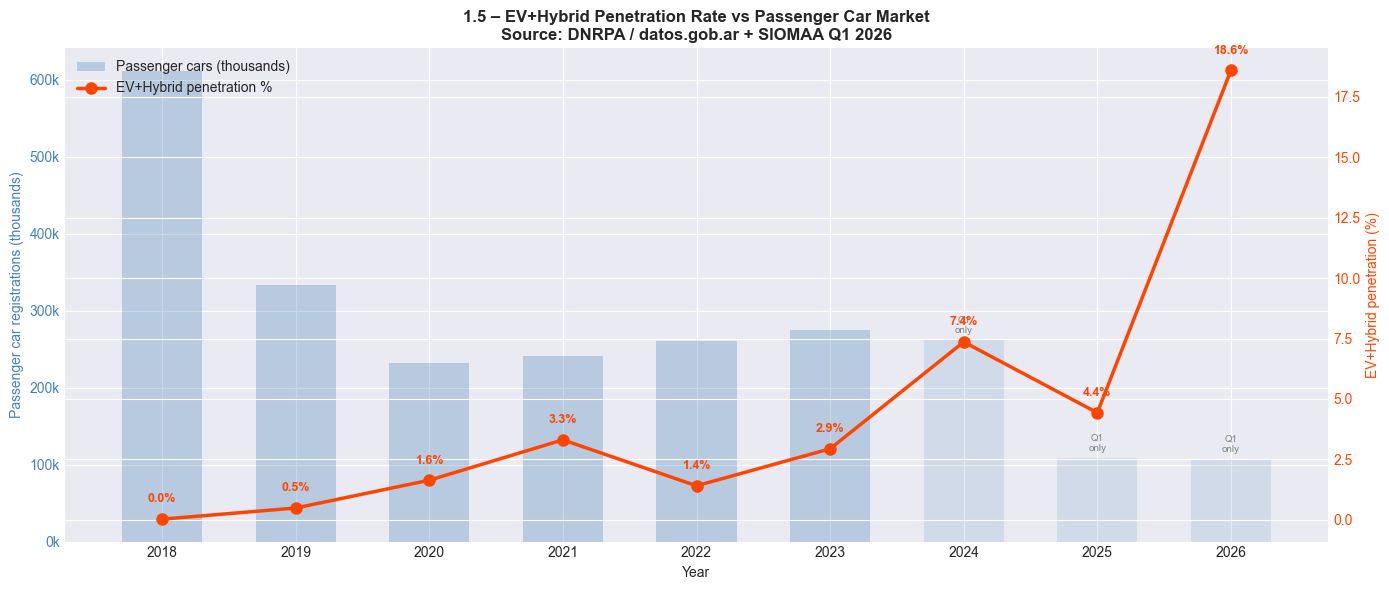


✅ Section 1.5 completed.


In [8]:
# ═══════════════════════════════════════════════════════════
# ⚡ 1.5 EV PENETRATION RATE (2018–2026)
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("⚡ 1.5 – EV PENETRATION RATE")
print("=" * 60)

# ── EV & Hybrid confirmed data ───────────────────────────────
# Source: SIOMAA Informe Trimestral Electromovilidad Q1 2026
# Note: 2025 and 2026 are Q1 only — annual data not available
ev_data = pd.DataFrame({
    "year":      [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    "ev_hybrid": [ 167, 1640, 3815, 7978, 3670, 8090, 19232, 4808, 19867],
    "period":    ["FY", "FY", "FY", "FY", "FY",  "FY", "FY est.", "Q1", "Q1"]
})

# ── Passenger cars per year (from monthly files) ─────────────
cars_annual = summary_v2.copy()

# ── For Q1 years, annualize cars too ────────────────────────
# 2025 Q1 cars
q1_2025_cars = df_cars[
    (df_cars["year"] == 2025) & (df_cars["month"] <= 3)
].shape[0]

q1_2026_cars = df_cars[
    (df_cars["year"] == 2026) & (df_cars["month"] <= 3)
].shape[0]

# ── Merge ────────────────────────────────────────────────────
df_pen = cars_annual.merge(ev_data, on="year", how="inner")

# ── Use Q1 cars for Q1 EV years ─────────────────────────────
df_pen.loc[df_pen["year"] == 2025, "cars_base"] = q1_2025_cars
df_pen.loc[df_pen["year"] == 2026, "cars_base"] = q1_2026_cars
df_pen["cars_base"] = df_pen["cars_base"].fillna(df_pen["registrations"])

# ── Penetration rate ─────────────────────────────────────────
df_pen["penetration_pct"] = (
    df_pen["ev_hybrid"] / df_pen["cars_base"] * 100
).round(2)

print(df_pen[["year", "cars_base", "ev_hybrid", "penetration_pct", "period"]].to_string(index=False))

# ── VISUALIZATION ────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))

colors = ["#FF6B6B" if p in ["Q1", "FY est."] else "steelblue"
          for p in df_pen["period"]]

bars = ax1.bar(df_pen["year"], df_pen["cars_base"] / 1000,
               color="steelblue", alpha=0.3, width=0.6,
               label="Passenger cars (thousands)")
ax1.set_ylabel("Passenger car registrations (thousands)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

ax2 = ax1.twinx()
ax2.plot(df_pen["year"], df_pen["penetration_pct"],
         color="orangered", marker="o", linewidth=2.5,
         markersize=8, label="EV+Hybrid penetration %")
ax2.set_ylabel("EV+Hybrid penetration (%)", color="orangered")
ax2.tick_params(axis="y", labelcolor="orangered")

for _, row in df_pen.iterrows():
    ax2.annotate(f"{row['penetration_pct']:.1f}%",
                 xy=(row["year"], row["penetration_pct"]),
                 xytext=(0, 12), textcoords="offset points",
                 ha="center", fontsize=9, color="orangered",
                 fontweight="bold")

# Mark Q1 bars
for i, row in df_pen.iterrows():
    if row["period"] in ["Q1", "FY est."]:
        ax1.get_children()[i].set_alpha(0.15)
        ax1.annotate("Q1\nonly", xy=(row["year"], row["cars_base"]/1000),
                     ha="center", fontsize=7, color="gray",
                     xytext=(0, 5), textcoords="offset points")

ax1.set_title("1.5 – EV+Hybrid Penetration Rate vs Passenger Car Market\n"
              "Source: DNRPA / datos.gob.ar + SIOMAA Q1 2026",
              fontweight="bold", fontsize=12)
ax1.set_xlabel("Year")
ax1.set_xticks(df_pen["year"])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()
print("\n✅ Section 1.5 completed.")

### 📌 Key Observations — EV+Hybrid Penetration (2018–2026)

- **2018–2021**: Gradual adoption driven by hybrid vehicles (HEV), reaching **3.3%** penetration
- **2022**: Sharp drop to **1.4%** — import restrictions and macroeconomic instability
- **2023–2024**: Recovery phase, reaching **7.4%** in Q1 2024
- **2026 Q1**: Penetration jumped to **18.6%** — direct impact of **Decreto 49/2025**, which established 0% tariffs for EV imports under USD 16k FOB
- The Q1 2026 data confirms a structural shift in the market, not a temporary spike

> **Note**: 2025 and 2026 values are Q1 only. Annual penetration for these years may differ as the regulatory quota (50,000 units/year) is already exhausted.

📊 1.6 – TECHNOLOGY MIX Q1 2025 vs Q1 2026
technology  q1_2025  q1_2026  growth_pct
       HEV     2593    11905       359.1
      MHEV      398     2835       612.3
      PHEV       63     3487      5434.9
       BEV     1754     1640        -6.5


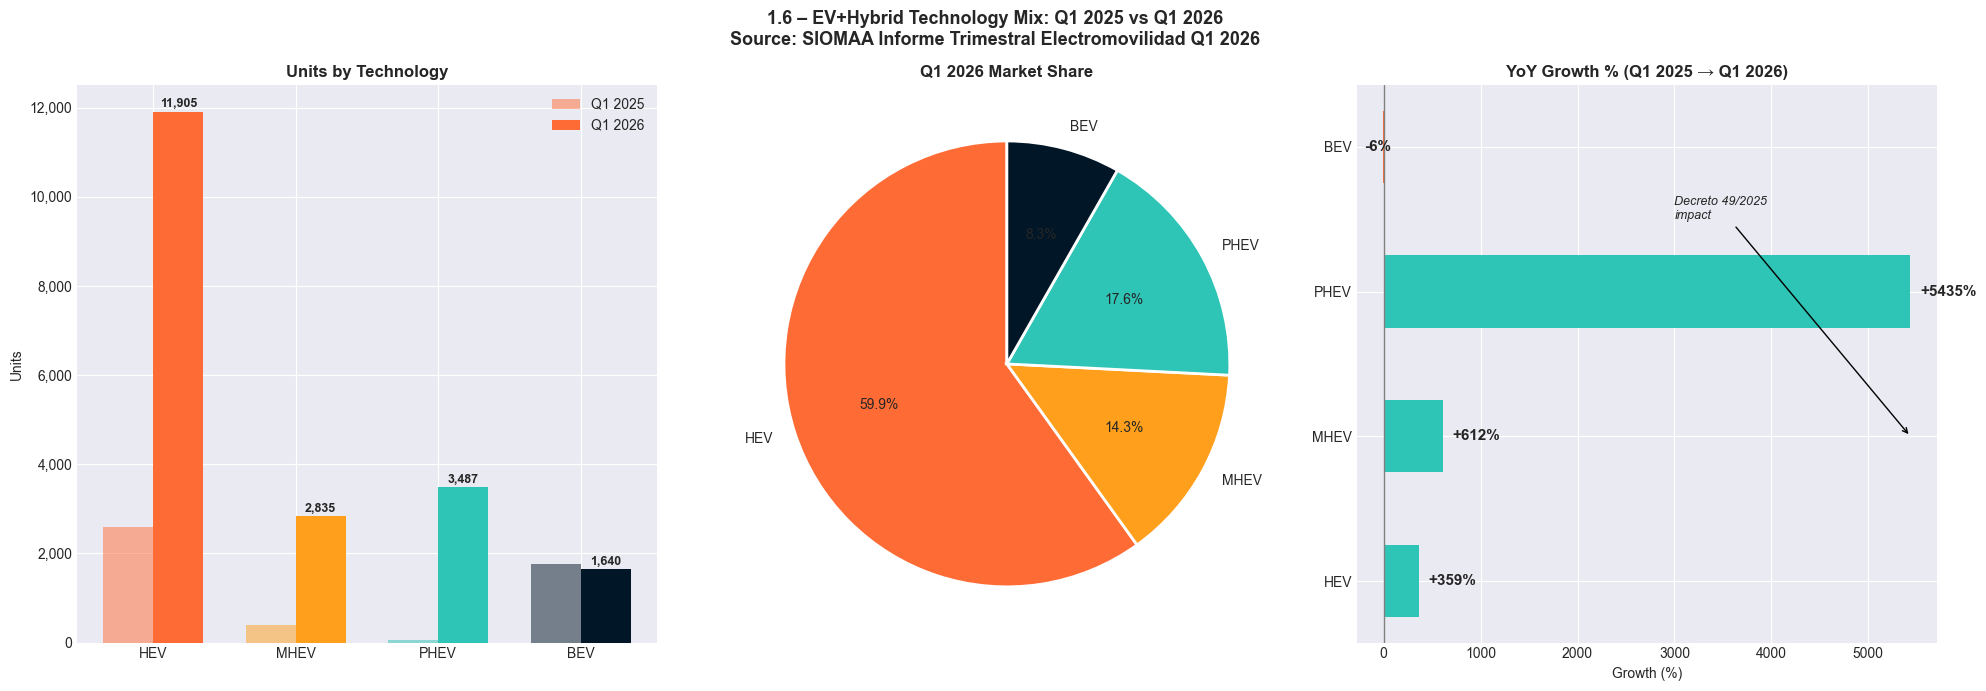


✅ Section 1.6 completed.


In [9]:
# ═══════════════════════════════════════════════════════════
# 📊 1.6 TECHNOLOGY MIX — Q1 2025 vs Q1 2026
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📊 1.6 – TECHNOLOGY MIX Q1 2025 vs Q1 2026")
print("=" * 60)

tech_data = pd.DataFrame({
    "technology": ["HEV", "MHEV", "PHEV", "BEV"],
    "q1_2025":    [2593,   398,    63,    1754],
    "q1_2026":    [11905,  2835,  3487,   1640],
})

tech_data["growth_pct"] = ((tech_data["q1_2026"] / tech_data["q1_2025"]) - 1) * 100
tech_data["growth_pct"] = tech_data["growth_pct"].round(1)

print(tech_data.to_string(index=False))

colors = ["#FF6B35", "#FF9F1C", "#2EC4B6", "#011627"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("1.6 – EV+Hybrid Technology Mix: Q1 2025 vs Q1 2026\n"
             "Source: SIOMAA Informe Trimestral Electromovilidad Q1 2026",
             fontweight="bold", fontsize=13)

# --- Chart 1: Grouped bar ---
ax = axes[0]
x = np.arange(len(tech_data))
w = 0.35
bars1 = ax.bar(x - w/2, tech_data["q1_2025"], w, label="Q1 2025",
               color=colors, alpha=0.5)
bars2 = ax.bar(x + w/2, tech_data["q1_2026"], w, label="Q1 2026",
               color=colors, alpha=1.0)
ax.set_title("Units by Technology", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tech_data["technology"])
ax.set_ylabel("Units")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{int(bar.get_height()):,}", ha="center", fontsize=9, fontweight="bold")

# --- Chart 2: Pie Q1 2026 ---
ax = axes[1]
ax.pie(tech_data["q1_2026"], labels=tech_data["technology"],
       colors=colors, autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Q1 2026 Market Share", fontweight="bold")

# --- Chart 3: Horizontal bar with color by positive/negative ---
ax = axes[2]
bar_colors = ["#2EC4B6" if g > 0 else "#FF6B35" for g in tech_data["growth_pct"]]
bars = ax.barh(tech_data["technology"], tech_data["growth_pct"],
               color=bar_colors, height=0.5)
ax.set_title("YoY Growth % (Q1 2025 → Q1 2026)", fontweight="bold")
ax.set_xlabel("Growth (%)")
ax.axvline(0, color="gray", linewidth=1)

for bar in bars:
    val = bar.get_width()
    label = f"+{val:.0f}%" if val > 0 else f"{val:.0f}%"
    xpos = val + 100 if val > 0 else val - 200
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=11, fontweight="bold")

# Add annotation for PHEV
ax.annotate("Decreto 49/2025\nimpact",
            xy=(5434, 1),
            xytext=(3000, 2.5),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, fontstyle="italic")

plt.tight_layout()
plt.show()
print("\n✅ Section 1.6 completed.")

### 📌 Key Observations — Technology Mix (Q1 2025 vs Q1 2026)

**The Argentine EV market experienced a dramatic structural shift in Q1 2026**, driven by the regulatory framework of Decreto 49/2025.

**HEV (Hybrid — Non-plug-in)** remains the dominant technology with 59.9% market share, growing +359% vs Q1 2025. The segment diversified significantly — while in Q1 2025 two models (Corolla and Corolla Cross) explained 93% of sales, in Q1 2026 six models share 80% of the volume, including new entrants like Ford Territory and BAIC BJ30.

**MHEV (Mild Hybrid)** grew +612%, now representing 14.3% of the EV market. Leadership shifted from European premium brands (Audi, Land Rover, Mercedes-Benz) to mass-market models like Chery Tiggo 7 and Renault Arkana.

**PHEV (Plug-in Hybrid)** is the standout story — growing +5,435% from just 63 units in Q1 2025 to 3,487 in Q1 2026. This segment was virtually non-existent before Decreto 49/2025 and is now 17.6% of the market, dominated by Chinese brands (BYD Song Pro, Changan CS55).

**BEV (100% Electric)** is the only segment that declined (-6%), dropping from 1,754 to 1,640 units. Despite having the largest model variety (42 models available), growth is constrained by **limited charging infrastructure** across Argentina — a key challenge this analysis addresses in the 2030 forecast.

> **Source**: SIOMAA Informe Trimestral sobre Electromovilidad Q1 2026 — ACARA

🌍 1.7 – VEHICLE ORIGIN: BEFORE & AFTER DECRETO 49/2025
 origin  q1_2025  q1_2026  growth_pct
  China       98     6063      6086.7
 Brazil     3640     4186        15.0
Uruguay      447     1786       299.6
  Japan      154      595       286.4
 Others      469     1237       163.8


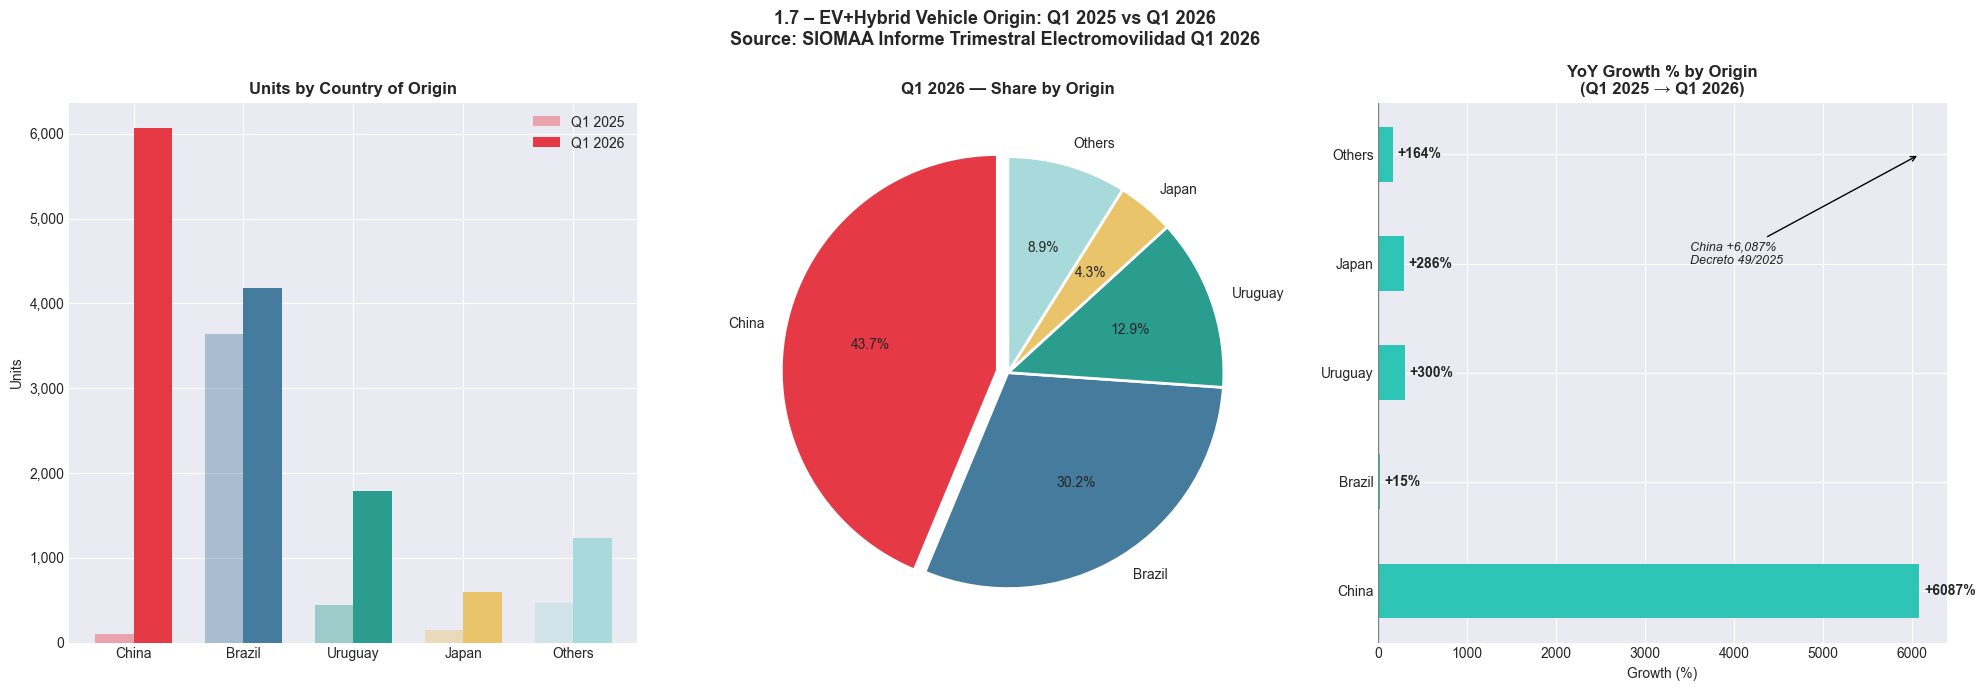


✅ Section 1.7 completed.


In [10]:
# ═══════════════════════════════════════════════════════════
# 🌍 1.7 VEHICLE ORIGIN — Impact of Decreto 49/2025
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🌍 1.7 – VEHICLE ORIGIN: BEFORE & AFTER DECRETO 49/2025")
print("=" * 60)

# ── Data from SIOMAA report ──────────────────────────────────
# Source: SIOMAA Q1 2026 — registrations by origin
origin_data = pd.DataFrame({
    "origin":   ["China", "Brazil", "Uruguay", "Japan", "Others"],
    "q1_2025":  [98,      3640,     447,       154,     469],
    "q1_2026":  [6063,    4186,     1786,      595,     1237],
})

origin_data["growth_pct"] = (
    (origin_data["q1_2026"] / origin_data["q1_2025"]) - 1
) * 100
origin_data["growth_pct"] = origin_data["growth_pct"].round(1)

print(origin_data.to_string(index=False))

# ── VISUALIZATION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("1.7 – EV+Hybrid Vehicle Origin: Q1 2025 vs Q1 2026\n"
             "Source: SIOMAA Informe Trimestral Electromovilidad Q1 2026",
             fontweight="bold", fontsize=13)

colors_origin = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#A8DADC"]

# --- Chart 1: Grouped bar ---
ax = axes[0]
x = np.arange(len(origin_data))
w = 0.35
ax.bar(x - w/2, origin_data["q1_2025"], w, label="Q1 2025",
       color=colors_origin, alpha=0.4)
ax.bar(x + w/2, origin_data["q1_2026"], w, label="Q1 2026",
       color=colors_origin, alpha=1.0)
ax.set_title("Units by Country of Origin", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(origin_data["origin"])
ax.set_ylabel("Units")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# --- Chart 2: Pie comparison ---
ax = axes[1]
ax.pie(origin_data["q1_2026"], labels=origin_data["origin"],
       colors=colors_origin, autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2),
       explode=[0.05, 0, 0, 0, 0])
ax.set_title("Q1 2026 — Share by Origin", fontweight="bold")

# --- Chart 3: Growth % horizontal ---
ax = axes[2]
bar_colors = ["#2EC4B6" if g > 0 else "#FF6B35" for g in origin_data["growth_pct"]]
bars = ax.barh(origin_data["origin"], origin_data["growth_pct"],
               color=bar_colors, height=0.5)
ax.set_title("YoY Growth % by Origin\n(Q1 2025 → Q1 2026)", fontweight="bold")
ax.set_xlabel("Growth (%)")
ax.axvline(0, color="gray", linewidth=1)

for bar in bars:
    val = bar.get_width()
    label = f"+{val:.0f}%" if val > 0 else f"{val:.0f}%"
    xpos = val + 50 if val > 0 else val - 100
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=10, fontweight="bold")

ax.annotate("China +6,087%\nDecreto 49/2025",
            xy=(6087, 4),
            xytext=(3500, 3),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, fontstyle="italic")

plt.tight_layout()
plt.show()
print("\n✅ Section 1.7 completed.")

### 📌 Key Observations — Vehicle Origin (Q1 2025 vs Q1 2026)

**The origin of EV+Hybrid vehicles in Argentina shifted dramatically** following the implementation of Decreto 49/2025, which established 0% tariffs for extrazone imports under USD 16k FOB.

**China** went from near-zero presence (98 units in Q1 2025) to leading the market with **6,063 units and 43.7% share** in Q1 2026 — a +6,087% increase. Chinese brands now dominate the PHEV and BEV segments, with BYD, BAIC, Haval, Chery, MG and Changan all posting significant volumes.

**Brazil** remains the second largest origin with 30.2% share, growing a modest +15%. Brazilian-origin vehicles are primarily HEVs (Toyota Corolla, Corolla Cross) — a mature segment with stable but slower growth compared to the Chinese extrazone surge.

**Uruguay** grew +300%, reflecting its role as a re-export hub for vehicles initially imported from extrazone markets.

**Japan** grew +286%, driven by Toyota HEV models assembled in Japan (RAV4, Yaris Cross).

> **Key insight**: The Decreto 49/2025 effectively opened the Argentine market to Chinese electric and plug-in hybrid vehicles at competitive price points. Brazil, traditionally the dominant supplier, maintained volume but lost significant market share — dropping from ~75% to

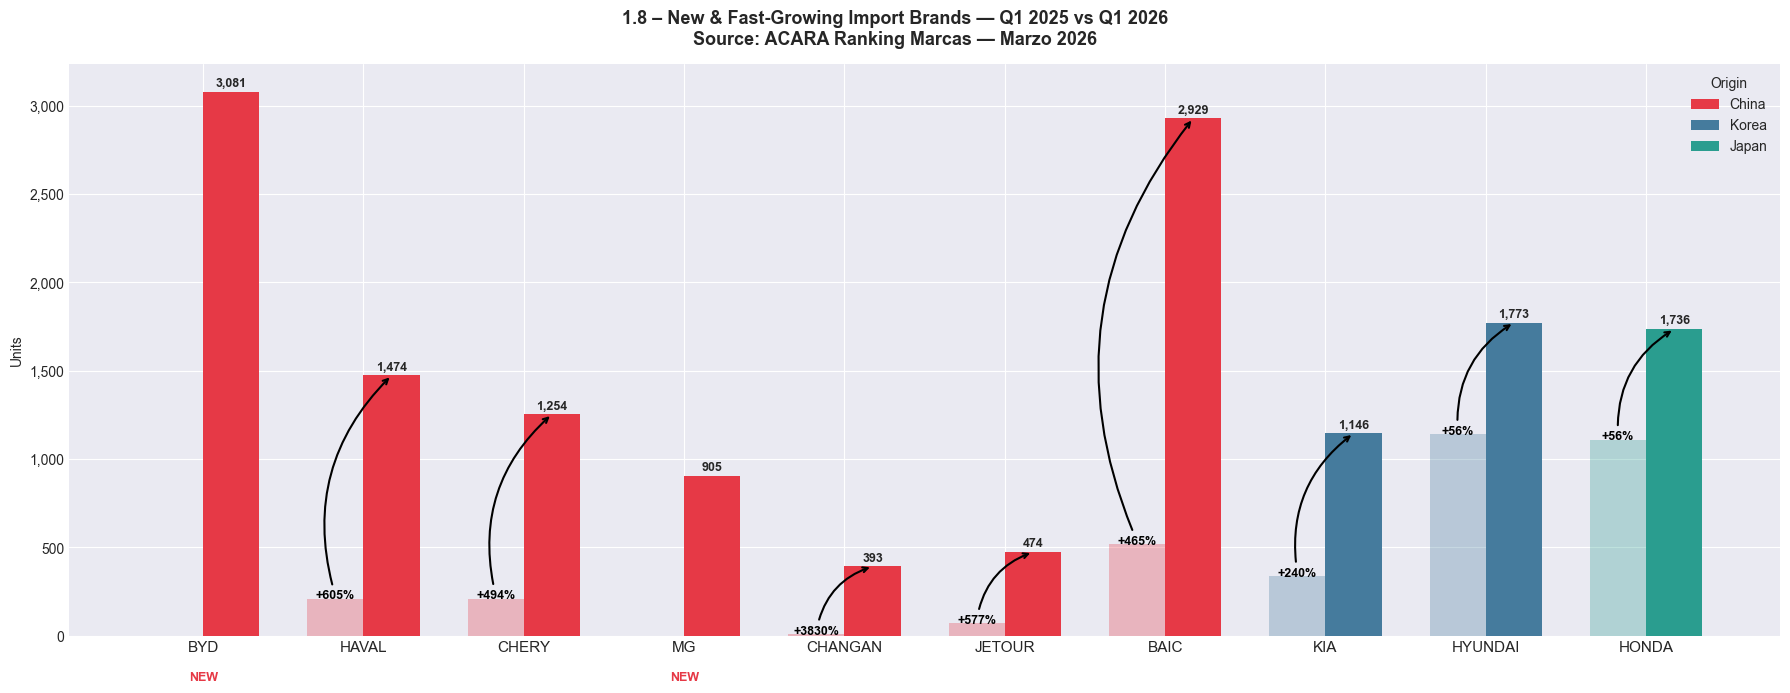


✅ Section 1.8 completed.


In [12]:
# ═══════════════════════════════════════════════════════════
# 🏭 1.8 NEW & FAST-GROWING IMPORT BRANDS
# ═══════════════════════════════════════════════════════════

# ── Define data ──────────────────────────────────────────────
brands_data = pd.DataFrame({
    "brand":      ["BYD", "HAVAL", "CHERY", "MG", "CHANGAN",
                   "JETOUR", "BAIC", "KIA", "HYUNDAI", "HONDA"],
    "q1_2025":    [0,      209,     211,     0,    10,
                   70,      518,     337,     1140,   1110],
    "q1_2026":    [3081,   1474,    1254,    905,  393,
                   474,     2929,    1146,    1773,   1736],
    "origin":     ["China", "China", "China", "China", "China",
                   "China", "China", "Korea", "Korea", "Japan"],
})

brands_data["growth_pct"] = brands_data.apply(
    lambda x: None if x["q1_2025"] == 0
    else round((x["q1_2026"] / x["q1_2025"] - 1) * 100, 1),
    axis=1
)
brands_data["is_new"] = brands_data["q1_2025"] == 0

origin_colors = {
    "China": "#E63946",
    "Korea": "#457B9D",
    "Japan": "#2A9D8F"
}

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle("1.8 – New & Fast-Growing Import Brands — Q1 2025 vs Q1 2026\n"
             "Source: ACARA Ranking Marcas — Marzo 2026",
             fontweight="bold", fontsize=13)

x = np.arange(len(brands_data))
w = 0.35
bar_colors = [origin_colors[o] for o in brands_data["origin"]]

ax.bar(x - w/2, brands_data["q1_2025"], w,
       color=bar_colors, alpha=0.3, label="Q1 2025")
bars2 = ax.bar(x + w/2, brands_data["q1_2026"], w,
               color=bar_colors, alpha=1.0, label="Q1 2026")

ax.set_xticks(x)
ax.set_xticklabels(brands_data["brand"], fontsize=11)
ax.set_ylabel("Units")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for i, row in brands_data.iterrows():
    ax.text(i + w/2, row["q1_2026"] + 30,
            f"{row['q1_2026']:,}",
            ha="center", fontsize=9, fontweight="bold")

for i, row in brands_data.iterrows():
    if row["is_new"]:
        ax.text(i, -250, "NEW",
                ha="center", fontsize=9,
                color="#E63946", fontweight="bold")
    else:
        ax.annotate(
            f"+{row['growth_pct']:.0f}%",
            xy=(i + w/2, row["q1_2026"]),
            xytext=(i - w/2, row["q1_2025"]),
            fontsize=9,
            color="black",
            fontweight="bold",
            ha="center",
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=1.5,
                connectionstyle="arc3,rad=-0.3"
            )
        )

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=o) for o, c in origin_colors.items()]
ax.legend(handles=legend_elements, title="Origin", loc="upper right")

plt.tight_layout()
plt.show()
print("\n✅ Section 1.8 completed.")

### 📌 Key Observations — New & Fast-Growing Import Brands (Q1 2025 vs Q1 2026)

**The Decreto 49/2025 triggered a wave of new brand entries** into the Argentine market, fundamentally reshaping the competitive landscape beyond traditional players.

**Chinese brands dominated the newcomer surge:**
- **BYD** and **MG** entered from zero — no registrations in Q1 2025, now ranking among the top 10 brands nationally
- **BAIC** grew +465%, consolidating as the leading Chinese brand with 2,929 units in Q1 2026
- **HAVAL** (+605%), **CHERY** (+494%), **CHANGAN** (+3,830%) and **JETOUR** (+577%) all posted explosive growth from very low bases

**Korean and Japanese brands also benefited**, though more moderately:
- **KIA** +240%, **HYUNDAI** +56%, **HONDA** +56% — these brands were already present but accelerated registrations as consumer confidence in non-traditional brands grew

**The structural shift is clear**: in Q1 2025 the market was dominated by European and Brazilian-assembled vehicles. By Q1 2026, 7 of the 10 fastest-growing brands are of Asian origin — 5 of them Chinese.

> **Note**: Growth percentages reflect the comparison between Q1 2025 and Q1 2026 full quarters. Brands marked NEW had zero registrations in Q1 2025.
> 
> **Source**: ACARA Ranking TOP 40 Marcas Livianos — Marzo 2026

---

## 🔮 2030 EV Market Forecast — Scenario Analysis

### Context & Methodology

All projections use **Q1 2026 as the base period** (January–March 2026), the most recent available data. Annual 2026 figures are estimated by multiplying Q1 values by 4 — a simplification that may differ from actual full-year results, which will be updated once 2026 annual data is available.

**Key political context**: Argentina's presidential elections are scheduled for **October 2027**. The current administration's Decreto 49/2025 — which established 0% tariffs for EV imports under USD 16k FOB — is the primary driver of the current EV boom. The election outcome is the single most important variable for the 2030 forecast.

---

### 📗 Scenario 1 — Continuity & Steady Growth
**"The decree holds, the market consolidates"**

**Political assumption**: Current administration is re-elected in 2027 and maintains Decreto 49/2025.

**Market assumptions**:
- The 50,000-unit annual import quota is gradually expanded to 80,000–100,000 units by 2028
- The initial Q1 2026 boom normalizes — growth decelerates as the market absorbs the first wave of demand
- Charging infrastructure grows moderately, primarily in Buenos Aires, Córdoba and Santa Fe
- Chinese brands consolidate their position; European and Brazilian brands adapt gradually

**Expected outcome by 2030**:
- EV+Hybrid penetration reaches **35–40%** of new car registrations
- ~180,000–220,000 EV+Hybrid units per year
- BEV segment grows but remains constrained by charging infrastructure gaps

---

### 📘 Scenario 2 — Continuity & Expansion Wave
**"The floodgates open — more models, lower prices, better infrastructure"**

**Political assumption**: Current administration is re-elected and deepens the electromobility agenda.

**Market assumptions**:
- Decreto 49/2025 is expanded — import quota raised from 50,000 to 150,000+ units annually
- New Chinese and Korean models enter at increasingly competitive price points (sub-USD 20k)
- National fast-charging network expands significantly — 500+ chargers deployed along major corridors (RN 7, RN 9, RN 14) reducing range anxiety for BEV buyers
- Provincial governments launch incentive programs — tax exemptions, preferential registration fees, toll discounts for EVs
- Local financing options for EVs improve — banks and OEMs offer EV-specific credit lines
- BEV segment accelerates as charging infrastructure gaps close
- Model availability grows from 121 (Q1 2026) to 200+ by 2028

**Expected outcome by 2030**:
- EV+Hybrid penetration reaches **55–60%** of new car registrations
- ~300,000–350,000 EV+Hybrid units per year
- PHEV and BEV segments grow significantly as infrastructure catches up with demand

---

### 📕 Scenario 3 — Political Shift & Import Restrictions
**"Back to protectionism — the boom reverses"**

**Political assumption**: Opposition wins the 2027 election and reverses or significantly limits Decreto 49/2025.

**Market assumptions**:
- Import tariffs are reinstated for extrazone vehicles — Chinese brands face 35%+ duties
- The 50,000-unit quota is eliminated or drastically reduced
- Brazilian-assembled HEVs (Toyota, Fiat) remain the only affordable electrified option
- Charging infrastructure investment stalls without regulatory certainty
- BEV and PHEV segments collapse — only premium European models remain

**Expected outcome by 2030**:
- EV+Hybrid penetration falls back to **6–8%** of new car registrations
- ~35,000–50,000 EV+Hybrid units per year
- Market reverts to pre-2025 structure, dominated by combustion engines and Brazilian HEVs

---

> **Disclaimer**: These scenarios are analytical projections based on available Q1 2026 data and stated policy assumptions. They do not constitute financial or investment advice. Actual results will depend on macroeconomic conditions, global EV trends, and political decisions beyond the scope of this analysis.

---

🔮 2.0 – 2030 EV MARKET FORECAST
📊 Base year: 2026
   Total market (annualized): 629,820
   EV+Hybrid (annualized):    79,468
   Penetration:               12.6%

📋 EV+Hybrid units by scenario:
Year    Scenario 1 — Steady Growt    Scenario 2 — Expansion Wa    Scenario 3 — Policy Rever  
2026        79,467 ( 12.6%)              79,467 ( 12.6%)              79,467 ( 12.6%)        
2027       127,600 ( 22.0%)             145,000 ( 25.0%)              81,200 ( 14.0%)        
2028       162,000 ( 27.0%)             210,000 ( 35.0%)              54,000 (  9.0%)        
2029       198,400 ( 32.0%)             285,200 ( 46.0%)              43,400 (  7.0%)        
2030       243,200 ( 38.0%)             371,200 ( 58.0%)              44,800 (  7.0%)        


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17560\259673312.py:152: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17560\259673312.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Usuario\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Usuario\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


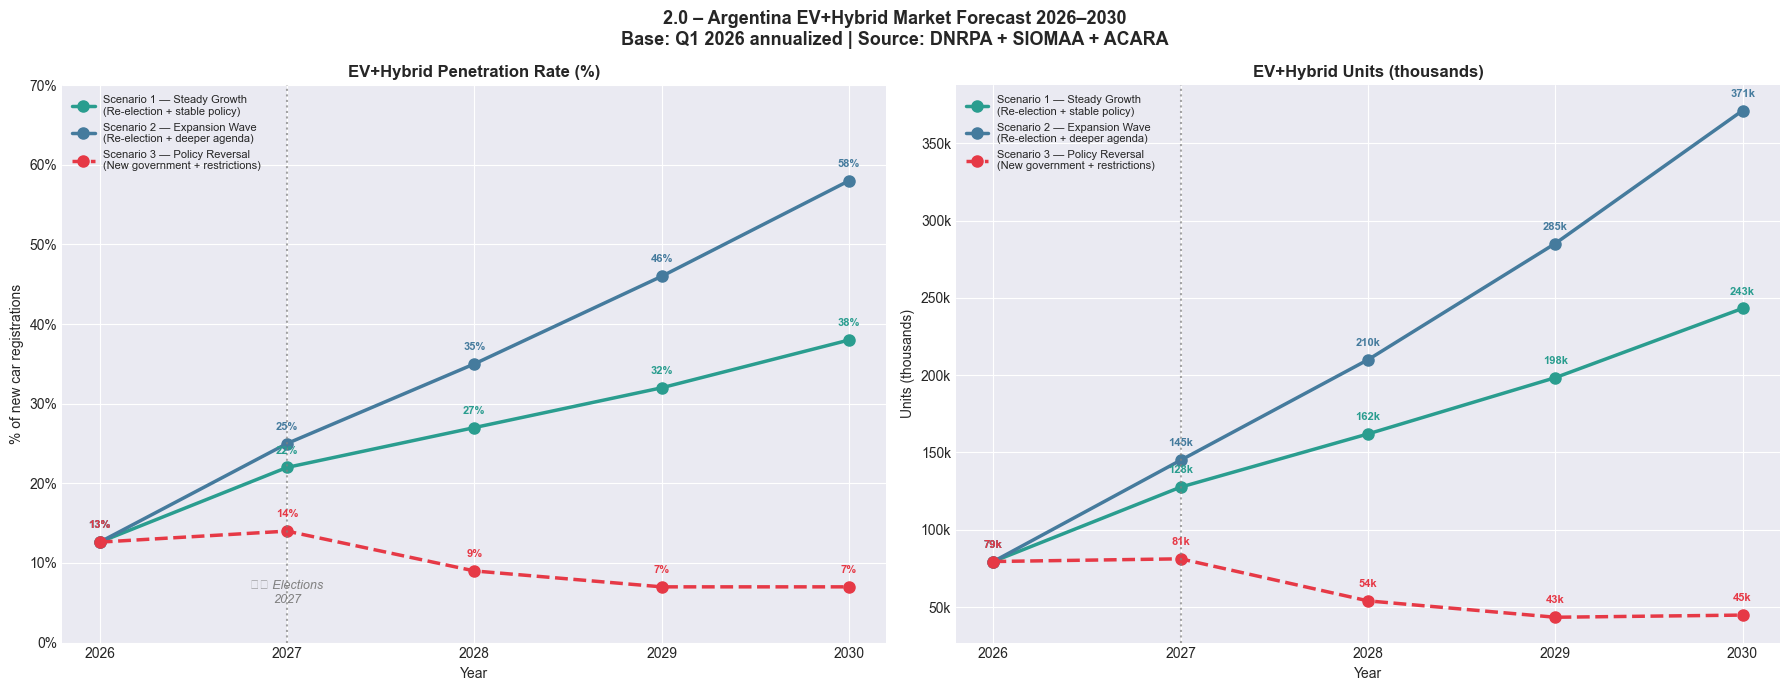


✅ Section 2.0 completed.


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔮 2.0 2030 EV MARKET FORECAST — SCENARIO ANALYSIS
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🔮 2.0 – 2030 EV MARKET FORECAST")
print("=" * 60)

# ── Base data (confirmed Q1 2026 annualized) ─────────────────
base_year = 2026
base_ev = 19867 * 4          # Q1 x4 annualized
base_market = 157455 * 4     # Q1 x4 annualized
base_penetration = base_ev / base_market * 100

print(f"📊 Base year: {base_year}")
print(f"   Total market (annualized): {base_market:,}")
print(f"   EV+Hybrid (annualized):    {base_ev:,}")
print(f"   Penetration:               {base_penetration:.1f}%")

# ── Forecast years ───────────────────────────────────────────
years = list(range(2026, 2031))

# ── Market size assumption (total passenger cars) ────────────
# Conservative: market recovers gradually to ~600k by 2030
market_size = {
    2026: base_market,
    2027: 580000,
    2028: 600000,
    2029: 620000,
    2030: 640000,
}

# ── Scenario penetration rates ───────────────────────────────
scenarios = {
    "Scenario 1 — Steady Growth\n(Re-election + stable policy)": {
        2026: base_penetration,
        2027: 22.0,
        2028: 27.0,
        2029: 32.0,
        2030: 38.0,
        "color": "#2A9D8F",
        "linestyle": "-"
    },
    "Scenario 2 — Expansion Wave\n(Re-election + deeper agenda)": {
        2026: base_penetration,
        2027: 25.0,
        2028: 35.0,
        2029: 46.0,
        2030: 58.0,
        "color": "#457B9D",
        "linestyle": "-"
    },
    "Scenario 3 — Policy Reversal\n(New government + restrictions)": {
        2026: base_penetration,
        2027: 14.0,
        2028: 9.0,
        2029: 7.0,
        2030: 7.0,
        "color": "#E63946",
        "linestyle": "--"
    },
}

# ── Calculate EV units per scenario ──────────────────────────
print("\n📋 EV+Hybrid units by scenario:")
print(f"{'Year':<6}", end="")
for s in scenarios:
    label = s.split("\n")[0][:25]
    print(f"  {label:<27}", end="")
print()

for year in years:
    print(f"{year:<6}", end="")
    for s, data in scenarios.items():
        ev_units = int(market_size[year] * data[year] / 100)
        print(f"  {ev_units:>10,} ({data[year]:>5.1f}%)        ", end="")
    print()

# ── VISUALIZATION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("2.0 – Argentina EV+Hybrid Market Forecast 2026–2030\n"
             "Base: Q1 2026 annualized | Source: DNRPA + SIOMAA + ACARA",
             fontweight="bold", fontsize=13)

# --- Chart 1: Penetration % by scenario ---
ax = axes[0]
for s, data in scenarios.items():
    pct_values = [data[y] for y in years]
    ax.plot(years, pct_values,
            color=data["color"],
            linestyle=data["linestyle"],
            linewidth=2.5,
            marker="o",
            markersize=8,
            label=s)
    for y, v in zip(years, pct_values):
        ax.annotate(f"{v:.0f}%",
                    xy=(y, v),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha="center", fontsize=8,
                    color=data["color"],
                    fontweight="bold")

ax.axvline(2027, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.annotate("🗳️ Elections\n2027",
            xy=(2027, 5), fontsize=9,
            color="gray", ha="center",
            fontstyle="italic")

ax.set_title("EV+Hybrid Penetration Rate (%)", fontweight="bold")
ax.set_ylabel("% of new car registrations")
ax.set_xlabel("Year")
ax.set_xticks(years)
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# --- Chart 2: EV units by scenario ---
ax = axes[1]
for s, data in scenarios.items():
    ev_units = [int(market_size[y] * data[y] / 100) for y in years]
    ax.plot(years, [u/1000 for u in ev_units],
            color=data["color"],
            linestyle=data["linestyle"],
            linewidth=2.5,
            marker="o",
            markersize=8,
            label=s)
    for y, v in zip(years, ev_units):
        ax.annotate(f"{v/1000:.0f}k",
                    xy=(y, v/1000),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha="center", fontsize=8,
                    color=data["color"],
                    fontweight="bold")

ax.axvline(2027, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
ax.annotate("🗳️ Elections\n2027",
            xy=(2027, 5), fontsize=9,
            color="gray", ha="center",
            fontstyle="italic")

ax.set_title("EV+Hybrid Units (thousands)", fontweight="bold")
ax.set_ylabel("Units (thousands)")
ax.set_xlabel("Year")
ax.set_xticks(years)
ax.legend(loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

plt.tight_layout()
plt.show()
print("\n✅ Section 2.0 completed.")

### 📌 Key Observations — 2030 Forecast

**The 2027 elections are the single most important variable** for Argentina's EV market trajectory. The three scenarios diverge sharply after that point.

**Scenario 1 — Steady Growth (38% penetration by 2030)**: A realistic baseline assuming policy continuity without major new incentives. The market absorbs the initial import wave and grows steadily, driven by HEV and PHEV segments.

**Scenario 2 — Expansion Wave (58% penetration by 2030)**: Requires active policy deepening — higher import quotas, charging infrastructure investment, and provincial incentives. At 371k units, Argentina would rank among the top EV markets in Latin America.

**Scenario 3 — Policy Reversal (7% penetration by 2030)**: A return to protectionist trade policy would effectively kill the momentum built in 2025-2026. Chinese brands would exit or drastically reduce presence; the market would revert to Brazilian HEVs as the only affordable electrified option.

> **Base**: Q1 2026 annualized (19,867 × 4 = ~79,468 EV+Hybrid units). Full year 2026 data will be available in early 2027 and should be used to recalibrate these projections.

In [ ]:
# ═══════════════════════════════════════════════════════════
# 🗺️ 3.0 CURRENT CHARGING NETWORK — BASE MAP (COMPLETE)
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🗺️ 3.0 – CURRENT EV CHARGING STATIONS IN ARGENTINA")
print("=" * 60)

stations_data = [
    # ── Ruta 7 corridor ──────────────────────────────────────
    ("Ruta 7 Peaje Desaguadero",    -32.65, -68.47, "Corredor RN7"),
    ("Ruta 7 Peaje La Cumbre",      -33.55, -67.18, "Corredor RN7"),
    ("Ruta 7 Peaje Justo Daract",   -33.67, -65.18, "Corredor RN7"),
    # ── Córdoba ──────────────────────────────────────────────
    ("YPF Rio Segundo Ascendente",  -31.65, -63.68, "Córdoba"),
    ("YPF Rio Segundo Descendente", -31.65, -63.66, "Córdoba"),
    ("YPF Lucam Córdoba",           -31.38, -64.18, "Córdoba"),
    ("YPF Vensim Córdoba",          -31.40, -64.20, "Córdoba"),
    ("YPF Punto Panorámico Córdoba",-31.42, -64.22, "Córdoba"),
    ("EPEC Córdoba",                -31.41, -64.19, "Córdoba"),
    ("EPEC Marcos Juárez",          -32.69, -62.10, "Córdoba"),
    ("Villa María EPEC",            -32.41, -63.24, "Córdoba"),
    ("Shopping Tierra Chica",       -31.42, -64.49, "Córdoba"),
    ("Equipel Córdoba",             -31.42, -64.18, "Córdoba"),
    ("Sierra Electricidad",         -31.42, -64.18, "Córdoba"),
    ("City Center",                 -31.42, -64.18, "Córdoba"),
    # ── Santa Fe / Rosario ───────────────────────────────────
    ("Shopping Plaza San Lorenzo",  -32.74, -60.73, "Santa Fe"),
    ("Parque Industrial Roldán",    -32.89, -60.90, "Santa Fe"),
    ("Pastorutti",                  -32.95, -60.65, "Santa Fe"),
    ("Greco",                       -32.94, -60.70, "Santa Fe"),
    ("Serra Electricidad Rosario",  -32.95, -60.64, "Santa Fe"),
    ("Contelec",                    -31.63, -60.70, "Santa Fe"),
    ("Dygelec",                     -31.73, -60.53, "Santa Fe"),
    ("Serra Electricidad SF",       -31.63, -60.70, "Santa Fe"),
    ("Serra Electricidad Pergamino",-33.73, -61.96, "Santa Fe"),
    ("Transelec Pergamino",         -33.89, -60.57, "Santa Fe"),
    # ── CABA ─────────────────────────────────────────────────
    ("Madero Harbour",              -34.61, -58.36, "CABA"),
    ("Paseo La Plaza",              -34.60, -58.38, "CABA"),
    ("Park 10",                     -34.62, -58.42, "CABA"),
    ("Nissan Neostar",              -34.61, -58.43, "CABA"),
    ("Punto 54",                    -34.61, -58.43, "CABA"),
    ("Vanluz",                      -34.61, -58.36, "CABA"),
    ("BP Soluciones Eléctricas",    -34.61, -58.36, "CABA"),
    ("Electropuerto",               -34.85, -58.35, "CABA"),
    # ── GBA Norte ────────────────────────────────────────────
    ("Camino de los Remeros",       -34.56, -58.68, "GBA Norte"),
    ("Tifón Water Planet",          -34.56, -58.68, "GBA Norte"),
    ("Andreani Norlog",             -34.52, -58.72, "GBA Norte"),
    ("Tamex 2",                     -34.52, -58.50, "GBA Norte"),
    ("Harmonie Chateau",            -34.47, -58.52, "GBA Norte"),
    ("Centro Logístico ALKO",       -34.47, -58.52, "GBA Norte"),
    ("Oficinas ALKO",               -34.47, -58.53, "GBA Norte"),
    ("Pelba Escobar",               -34.35, -58.79, "GBA Norte"),
    # ── GBA Oeste ────────────────────────────────────────────
    ("Electro Luján",               -34.57, -59.11, "GBA Oeste"),
    ("Pelba Pilar",                 -34.46, -58.91, "GBA Oeste"),
    # ── GBA Sur ──────────────────────────────────────────────
    ("Electricidad Solari",         -34.76, -58.40, "GBA Sur"),
    ("Magnani Soluciones",          -34.92, -57.95, "GBA Sur"),
    ("Fegime Latam",                -34.87, -58.50, "GBA Sur"),
    ("Trielec",                     -34.85, -58.52, "GBA Sur"),
    ("JOMA Electricidad",           -34.92, -57.95, "GBA Sur"),
    ("Richetta Schneider",          -34.85, -58.52, "GBA Sur"),
    ("Pem",                         -34.65, -58.62, "GBA Sur"),
    ("Nuevo Sur",                   -34.66, -58.60, "GBA Sur"),
    ("Ciardi Hnos Main",            -34.66, -58.60, "GBA Sur"),
    # ── Buenos Aires Interior ─────────────────────────────────
    ("YPF Dolores",                 -36.31, -57.68, "Buenos Aires"),
    ("Ciardi Hnos Balcarce",        -37.84, -58.25, "Buenos Aires"),
    ("Ciardi Hnos La Costa",        -37.11, -56.86, "Buenos Aires"),
    ("Electricidad Alsina",         -36.88, -60.02, "Buenos Aires"),
    ("Electricidad Maza",           -38.72, -62.27, "Buenos Aires"),
    ("Melecsur",                    -38.72, -62.28, "Buenos Aires"),
    ("Tandil",                      -37.32, -59.13, "Buenos Aires"),
    ("Mar del Plata 1",             -38.00, -57.55, "Buenos Aires"),
    ("Mar del Plata 2",             -38.02, -57.54, "Buenos Aires"),
    ("Mar del Plata 3",             -38.04, -57.53, "Buenos Aires"),
    ("9 de Julio",                  -35.45, -60.88, "Buenos Aires"),
    ("Santa Rosa La Pampa",         -36.62, -64.29, "La Pampa"),
    ("General Pico",                -35.65, -63.68, "La Pampa"),
    # ── Mendoza ──────────────────────────────────────────────
    ("Electro 2001",                -32.89, -68.84, "Mendoza"),
    ("Electro Dos",                 -32.90, -68.83, "Mendoza"),
    ("Centro Comercial Gomez Pardo",-32.89, -68.84, "Mendoza"),
    ("Terrazas del Portezuelo",     -32.89, -68.83, "Mendoza"),
    ("San Rafael Mendoza",          -34.62, -68.33, "Mendoza"),
    # ── San Luis ─────────────────────────────────────────────
    ("Equipel San Luis",            -33.30, -66.34, "San Luis"),
    ("Nuevo Sur San Luis",          -33.30, -66.33, "San Luis"),
    ("FG Industrial",               -33.67, -65.46, "San Luis"),
    # ── San Juan ─────────────────────────────────────────────
    ("San Juan Capital",            -31.53, -68.53, "San Juan"),
    # ── NOA ──────────────────────────────────────────────────
    ("BP Salta",                    -24.79, -65.41, "NOA"),
    ("BP Yerba Buena",              -26.81, -65.29, "NOA"),
    ("Parque Mitre Salta",          -27.45, -65.28, "NOA"),
    ("Matelec Catamarca",           -28.47, -65.78, "NOA"),
    # ── Neuquén ──────────────────────────────────────────────
    ("Neuquén Scame 1",             -38.92, -68.09, "Neuquén"),
    ("Neuquén Scame 2",             -38.95, -68.07, "Neuquén"),
    ("Neuquén Scame 3",             -38.97, -68.06, "Neuquén"),
    # ── Patagonia ────────────────────────────────────────────
    ("Comodoro Conocimiento",       -45.86, -67.49, "Patagonia"),
    ("Puerto Madryn",               -42.77, -65.04, "Patagonia"),
    # ── Entre Ríos ───────────────────────────────────────────
    ("Cooperativa Eléctrica Gualeguaychú", -33.01, -58.52, "Entre Ríos"),
]

stations = pd.DataFrame(stations_data,
                         columns=["name", "lat", "lon", "region"])

print(f"✅ Total stations: {len(stations)}")
print(f"\n📊 By region:")
print(stations["region"].value_counts().to_string())

# ── Interactive map ──────────────────────────────────────────
import folium

region_colors = {
    "CABA":          "red",
    "GBA Norte":     "orange",
    "GBA Oeste":     "orange",
    "GBA Sur":       "orange",
    "Buenos Aires":  "blue",
    "La Pampa":      "blue",
    "Córdoba":       "green",
    "Santa Fe":      "cadetblue",
    "Entre Ríos":    "cadetblue",
    "Mendoza":       "purple",
    "San Juan":      "purple",
    "San Luis":      "darkpurple",
    "Corredor RN7":  "black",
    "NOA":           "darkred",
    "Neuquén":       "darkblue",
    "Patagonia":     "darkblue",
}

m = folium.Map(location=[-38.0, -63.0], zoom_start=5,
               tiles="CartoDB positron")

for _, row in stations.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=8,
        color=region_colors.get(row["region"], "gray"),
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>Region: {row['region']}",
            max_width=200),
        tooltip=row["name"]
    ).add_to(m)

m.save("charging_stations_current.html")
print("\n✅ Map saved — open 'charging_stations_current.html'")
print(f"   Total stations mapped: {len(stations)}")

🗺️ 3.0 – CURRENT EV CHARGING STATIONS IN ARGENTINA
✅ Total stations: 84

📊 By region:
region
Córdoba         12
Buenos Aires    11
Santa Fe        10
GBA Sur          9
GBA Norte        8
CABA             8
Mendoza          5
NOA              4
Neuquén          3
Corredor RN7     3
San Luis         3
GBA Oeste        2
Patagonia        2
La Pampa         2
San Juan         1
Entre Ríos       1

✅ Map saved — open 'charging_stations_current.html'
   Total stations mapped: 84


In [13]:
# ── Download Argentina shapefile locally ─────────────────────
import urllib.request
import zipfile
import os

# Download from Natural Earth
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
urllib.request.urlretrieve(url, "ne_countries.zip")

with zipfile.ZipFile("ne_countries.zip", "r") as z:
    z.extractall("ne_countries")

print("✅ Shapefile downloaded")

✅ Shapefile downloaded
